In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from sklearn.preprocessing import MinMaxScaler

import json
import os
import time
from skimage.metrics import structural_similarity as ssim
from sklearn.metrics import mean_squared_error
from math import log10
import models
from processdata import TimeSeriesDataset




In [2]:
# Caminho do arquivo .npy
# npy_file_path = r"/home/romulo/Downloads/prmsl_data.npy"
# npy_file_path = r"/home/romulo/Downloads/qmax.2m.1836_data_mavg.npy"
npy_file_path = r"/home/romulo/migoogledrive/shred-jan/pyshred/Data/16_roll7_Re1_Wi3.5_beta0.6666/fields.npy"

save_path = r'./home/romulo/Documentos/lpips-env/results/cshred/oldroyd_test/csshred'

# Verifica a disponibilidade de GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Função para carregar dados de um arquivo .npy
def load_data(npy_file_path, time_slice):
    data_array = data = np.load(
    npy_file_path,allow_pickle=True
    )
    data_array = data_array.item()["trace_A"]
    data_array = data_array[:,:,time_slice:]
    data_array = np.transpose(data_array, (2,0,1))
    print("Loaded data dimensions:", data_array.shape)
    return data_array

Using device: cuda


In [3]:
# Carregamento dos dados
matrix = load_data(npy_file_path, time_slice=0)

Loaded data dimensions: (1433, 128, 128)


In [10]:

# Visualização dos dados 2D ou 3D
def visualize_data(matrix, subsampled):
    # Plot para o último slice temporal da matriz
    plt.imshow(matrix[-1, :, :], cmap="hot", origin="lower")
    plt.colorbar()
    plt.title("Last Temporal Slice")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.show()


    # Plot para o último slice temporal da matriz subsample
    plt.imshow(subsampled[:, :, -1], cmap="hot", origin="lower")
    plt.colorbar()
    plt.title("Last Temporal Slice (Subsampled)")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.show()

     # Plot para o último slice temporal da matriz subsample
    plt.imshow(subsampled[:, :, 300], cmap="hot", origin="lower")
    plt.colorbar()
    plt.title("Last Temporal Slice (Subsampled)")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.show()

In [11]:

# Subamostragem dos dados
# def subsample(snapshot, percent_subsample):
    
#     np.random.seed(1001)
#     print('snapshot', snapshot.shape)

#     snapshot = np.transpose(snapshot, (1, 2, 0))
#     num_cols_subsample = int(snapshot.shape[1] * percent_subsample)
#     snapshot_subsampled = snapshot.copy()

#     for i in range(snapshot.shape[2]):
#         random_indices = np.random.choice(
#             snapshot.shape[1], size=num_cols_subsample, replace=False
#         )
#         random_indices = sorted(random_indices)
#         diff_indices = np.diff(random_indices)
#         for j in range(len(random_indices) - 1):
#             if diff_indices[j] > 4:
#                 random_indices[j + 1] = random_indices[j] + 3

#         snapshot_subsampled[:, random_indices, i] = 0

#     print("Forma do snapshot após subamostragem:", snapshot.shape)
#     return snapshot_subsampled


# def subsample(snapshot, num_cols_subsample, num_snapshots_subsample):
    
#     np.random.seed(1001)

#     print('snapshot', snapshot.shape)

#     snapshot = np.transpose(snapshot, (1, 2, 0))
#     dim_x, dim_y, dim_t = snapshot.shape
#     snapshot_subsampled = snapshot.copy()

#     # Escolha aleatória das colunas a serem mantidas (não subamostradas)
#     cols_to_keep = np.random.choice(dim_y, size=dim_y - num_cols_subsample, replace=False)
#     cols_to_keep = sorted(cols_to_keep)

#     # Escolha aleatória dos snapshots a serem mantidos (não subamostrados)
#     snapshots_to_keep = np.random.choice(dim_t, size=dim_t - num_snapshots_subsample, replace=False)

#     # Criar uma máscara de uns
#     mask = np.ones((dim_x, dim_y, dim_t), dtype=bool)

#     # Definir os valores a serem subamostrados como False na máscara
#     mask[:, cols_to_keep, :] = False
#     mask[:, :, snapshots_to_keep] = False

#     # Aplicar a máscara
#     snapshot_subsampled[mask] = 0

#     print("Forma do snapshot após subamostragem:", snapshot_subsampled.shape)
#     return snapshot_subsampled

## Possivel correção 
def subsample(snapshot, num_cols_subsample, num_snapshots_subsample):
    
    np.random.seed(1001)

    print('snapshot', snapshot.shape)

    snapshot = np.transpose(snapshot, (1, 2, 0))
    dim_x, dim_y, dim_t = snapshot.shape
    snapshot_subsampled = snapshot.copy()

    # Escolha aleatória dos snapshots a serem subamostrados, garantindo que o último snapshot esteja incluído
    snapshots_to_subsample = np.random.choice(dim_t - 1, size=num_snapshots_subsample - 1, replace=False)
    snapshots_to_subsample = np.append(snapshots_to_subsample, dim_t - 1)  # Adiciona o último snapshot
    snapshots_to_subsample = np.sort(snapshots_to_subsample)

    # Escolha aleatória das colunas a serem subamostradas
    cols_to_subsample = np.random.choice(dim_y, size=num_cols_subsample, replace=False)

    # Criar uma máscara de uns
    mask = np.ones((dim_x, dim_y, dim_t), dtype=bool)

    # Aplicar subamostragem de colunas nos snapshots escolhidos
    for t in snapshots_to_subsample:
        mask[:, cols_to_subsample, t] = True

    # Aplicar a máscara
    snapshot_subsampled[mask] = 0

    print("Forma do snapshot após subamostragem:", snapshot_subsampled.shape)
    return snapshot_subsampled

# Uso da função
num_cols_subsample = int(matrix.shape[2] * 0.9)  # % das colunas serão subamostradas
num_snapshots_subsample = int(matrix.shape[0] * 0.8)  #  % dos snapshots serão subamostrados
snapshot = subsample(matrix, num_cols_subsample, num_snapshots_subsample)




snapshot (1433, 128, 128)
Forma do snapshot após subamostragem: (128, 128, 1433)


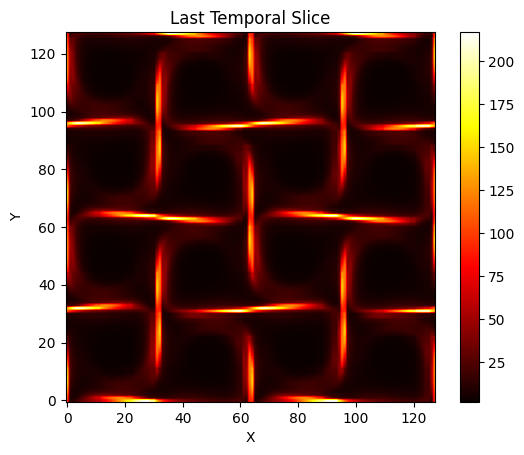

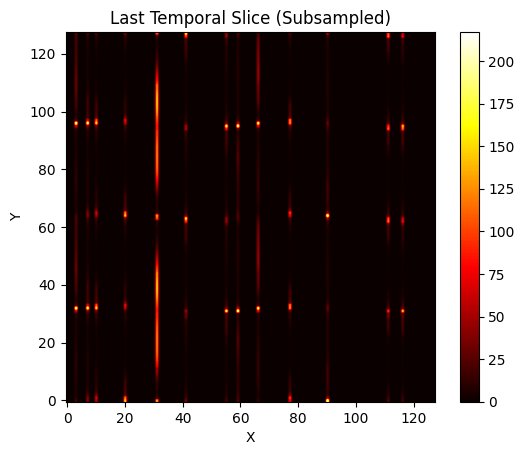

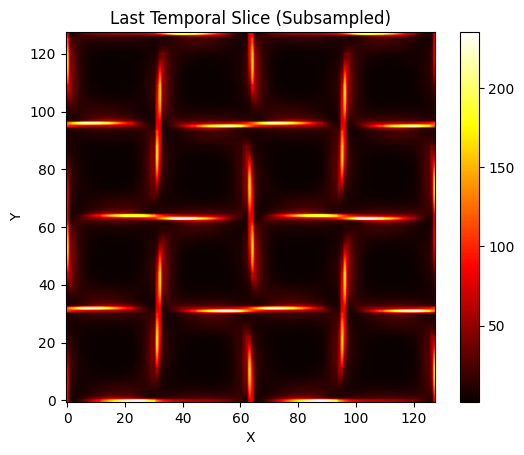

In [12]:
# Subamostragem e visualização dos dados
# percent_subsample = 0.3
# snapshot = matrix
# snapshot = subsample(snapshot, percent_subsample)
visualize_data(matrix, snapshot)

Forma do snapshot após subamostragem: (128, 128, 1433)
Plot saved to ./home/romulo/Documentos/lpips-env/results/shred/oldroyd/plot_din_CS-SHRED.png


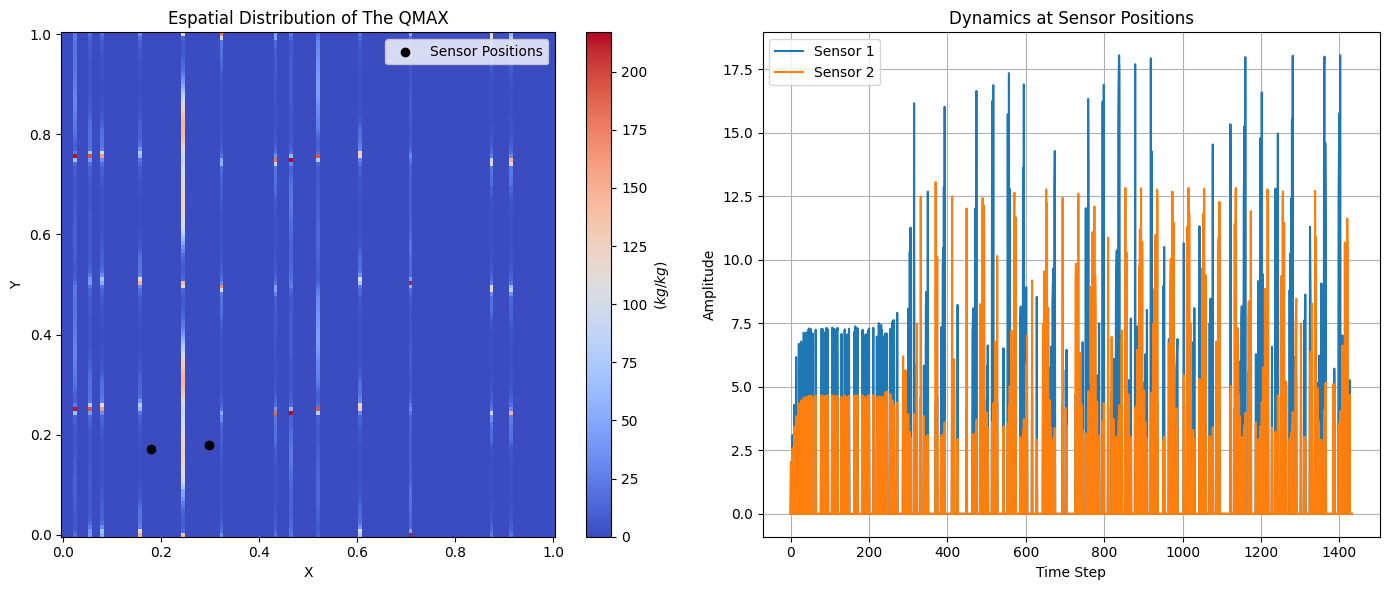

train_size 1003
val_size 286
test_size 143
trace_A (128, 128, 1433)
trace_A (128, 128, 1433)
1433 16384
device: cuda
Número de sensores:2
LambdaL2: 0.37697815730679735, LambdaL1: 0.013110681923458177, LambdaSNR: 0.0037632278472859095
Training epoch 1
Training Error: 0.0443130899220705
Validation Error:0.12962666153907776
SNR:-0.0014552940847352147
LambdaL2: 0.37697815730679735, LambdaL1: 0.013110681923458177, LambdaSNR: 0.0037632278472859095
Training epoch 50
Training Error: 0.020341195166110992
Validation Error:0.01041986234486103
SNR:5.933684349060059
LambdaL2: 0.37697815730679735, LambdaL1: 0.013110681923458177, LambdaSNR: 0.0037632278472859095
Training epoch 100
Training Error: 0.01648868713527918
Validation Error:0.0069252015091478825
SNR:8.153087615966797
LambdaL2: 0.37697815730679735, LambdaL1: 0.013110681923458177, LambdaSNR: 0.0037632278472859095
Training epoch 150
Training Error: 0.015751652419567108
Validation Error:0.006920537445694208
SNR:8.40226936340332
LambdaL2: 0.37697

In [7]:
# Configuração dos sensores
def plot_dynamics_at_sensors(
    trace_A, num_sensors, locations="c", show_plot=False, save_plot=True, save_path=save_path, file_name="plot_din.png", seed=101,
    auto_close_time=5
):
    np.random.seed(seed)

    dim_x, dim_y, dim_t = trace_A.shape

    print("Forma do snapshot após subamostragem:", trace_A.shape)

    if locations == "a":
        central_x, central_y = 0.5, 0.5
        sensor_locations = np.random.choice(dim_x * dim_y, num_sensors, replace=False)
        sensor_positions_x = sensor_locations % dim_x / dim_x
        sensor_positions_y = sensor_locations // dim_y / dim_y

        sensor_positions_x = np.append(sensor_positions_x, central_x)
        sensor_positions_y = np.append(sensor_positions_y, central_y)

    elif locations == "b":
        sensor_positions_x, sensor_positions_y = [0.5], [0.5]

    else:
        sensor_locations = np.random.choice(dim_x * dim_y, num_sensors, replace=False)
        sensor_positions_x = sensor_locations % dim_x / dim_x
        sensor_positions_y = sensor_locations // dim_y / dim_y

    sensor_temperature_history = []
    for t in range(dim_t):
        sensor_temperatures = [
            trace_A[int(dim_x * x), int(dim_y * y), t]
            for x, y in zip(sensor_positions_x, sensor_positions_y)
        ]
        sensor_temperature_history.append(sensor_temperatures)
    if show_plot or save_plot:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

        y = np.linspace(0, 1, int(dim_x))
        x = np.linspace(0, 1, int(dim_y))
        X, Y = np.meshgrid(x, y)

        cmap = ax1.pcolormesh(
            X, Y, trace_A[:, :, -1].real, shading="auto", cmap="coolwarm"
        )
        fig.colorbar(cmap, ax=ax1, label=r"$(kg/kg)$")
        ax1.set_title("Espatial Distribution of The QMAX")
        ax1.set_xlabel("X")
        ax1.set_ylabel("Y")

        ax1.scatter(
            sensor_positions_x,
            sensor_positions_y,
            color="k",
            label="Sensor Positions",
        )
        ax1.legend()

        sensor_temperature_history = np.array(sensor_temperature_history)
        for i, sensor_data in enumerate(sensor_temperature_history.T):
            ax2.plot(range(dim_t), sensor_data, label=f"Sensor {i+1}")

        ax2.set_xlabel("Time Step")
        ax2.set_ylabel("Amplitude")
        ax2.set_title("Dynamics at Sensor Positions")
        ax2.legend()
        ax2.grid(True)

        plt.tight_layout()

        if save_plot:
            if save_path:
                if not os.path.exists(save_path):
                    os.makedirs(save_path)
                save_file = os.path.join(save_path, file_name)
            else:
                save_file = file_name
            plt.savefig(save_file)
            print(f"Plot saved to {save_file}")

        if show_plot:
            plt.show()
            # time.sleep(auto_close_time)  # Espera por um tempo específico
            # plt.close(fig)
        else:
            plt.close(fig)

    return sensor_locations, sensor_positions_x, sensor_positions_y


# Preparação dos dados para treinamento e validação
def prepare_datasets(trace_A, trace_A_ori, num_sensors, sensor_locations, lags):
    trace_A_ori = np.transpose(trace_A_ori, (1, 2, 0))
    num_sensors = num_sensors

    dim_x, dim_y, dim_t = trace_A.shape

    lags = lags
    train_size = int(0.7 * trace_A.shape[2])
    val_size = int(0.2 * trace_A.shape[2])
    test_size = int(0.1 * trace_A.shape[2])

    print("train_size", train_size)
    print("val_size", val_size)
    print("test_size", test_size)

    print("trace_A", trace_A.shape)
    print("trace_A", trace_A_ori.shape)

    load_X = trace_A.reshape(dim_x * dim_y, dim_t).T
    load_X_test = trace_A_ori.reshape(dim_x * dim_y, dim_t).T

    load_X_shape_0, load_X_shape_1 = load_X.shape
    print(load_X_shape_0, load_X_shape_1)

    # Garantindo que os tamanhos não ultrapassem o tamanho real dos dados
    total_size = train_size + val_size + test_size
    if total_size > load_X_shape_0 - lags:
        train_size = (train_size * (load_X_shape_0 - lags)) // total_size
        val_size = (val_size * (load_X_shape_0 - lags)) // total_size
        test_size = (test_size * (load_X_shape_0 - lags)) // total_size

    train_indices = np.random.choice(
        load_X_shape_0 - lags, size=train_size, replace=False
    )
    mask = np.ones(load_X_shape_0 - lags)
    mask[train_indices] = 0
    valid_test_indices = np.arange(0, load_X_shape_0 - lags)[np.where(mask != 0)[0]]

    valid_indices = valid_test_indices[:val_size]
    test_indices = valid_test_indices[val_size : val_size + test_size]

    sc = MinMaxScaler()
    sc = sc.fit(load_X[train_indices])
    transformed_X = sc.transform(load_X)

    sc_test = sc.fit(load_X_test[train_indices])
    transformed_X_test = sc.transform(load_X_test)

    all_data_in = np.zeros((load_X_shape_0 - lags, lags, num_sensors))
    all_data_in_test = np.zeros((load_X_shape_0 - lags, lags, num_sensors))
    for i in range(load_X_shape_0 - lags):
        for j, loc in enumerate(sensor_locations):
            all_data_in[i, :, j] = transformed_X[i : i + lags, loc]
            all_data_in_test[i, :, j] = transformed_X_test[i : i + lags, loc]

    print("device:", device)
    print("Número de sensores:{}".format(num_sensors))

    train_data_in = torch.tensor(all_data_in[train_indices], dtype=torch.float32).to(
        device
    )
    valid_data_in = torch.tensor(all_data_in[valid_indices], dtype=torch.float32).to(
        device
    )
    test_data_in = torch.tensor(all_data_in[test_indices], dtype=torch.float32).to(
        device
    )
    test_data_in_test = torch.tensor(
        all_data_in_test[test_indices], dtype=torch.float32
    ).to(device)

    train_data_out = torch.tensor(
        transformed_X[train_indices + lags - 1], dtype=torch.float32
    ).to(device)
    valid_data_out = torch.tensor(
        transformed_X[valid_indices + lags - 1], dtype=torch.float32
    ).to(device)
    test_data_out = torch.tensor(
        transformed_X[test_indices + lags - 1], dtype=torch.float32
    ).to(device)
    test_data_out_test = torch.tensor(
        transformed_X_test[test_indices + lags - 1], dtype=torch.float32
    ).to(device)

    train_dataset = TimeSeriesDataset(train_data_in, train_data_out)
    valid_dataset = TimeSeriesDataset(valid_data_in, valid_data_out)
    test_dataset = TimeSeriesDataset(test_data_in, test_data_out)
    test_dataset_test = TimeSeriesDataset(test_data_in_test, test_data_out_test)

    return train_dataset, valid_dataset, test_dataset_test, sc, load_X_shape_1


# Treinamento e validação do modelo
def train_and_validate_model(
    type_model,
    model,
    train_dataset,
    valid_dataset,
    num_epochs,
    batch_size,
    lr,
    lambL2,
    lambL1,
    lambdaSNR,
    step_epoch,
    verbose,
    patience,
):
    if type_model == "CS-SHRED":
        train_error, validation_errors = models.fit_csshred_model(
            model,
            train_dataset,
            valid_dataset,
            batch_size=batch_size,
            num_epochs=num_epochs,
            lr=lr,
            lambL2=lambL2,
            lambL1=lambL1,
            lambdaSNR=lambdaSNR,
            step_epoch=step_epoch,
            verbose=verbose,
            patience=patience,
        )
        return train_error, validation_errors
    else:
        validation_errors = models.fit(
            model,
            train_dataset,
            valid_dataset,
            batch_size=batch_size,
            num_epochs=num_epochs,
            lr=lr,
            step_epoch=step_epoch,
            verbose=True,
            patience=patience,
        )
        return validation_errors


def evaluate_model(model, test_dataset, sc, json_save_path=save_path +'/error_results.json'):
    """
    Avalia o modelo calculando o erro normalizado e o SSIM entre as previsões e o ground truth.

    :param model: O modelo treinado.
    :param test_dataset: O conjunto de dados de teste.
    :param sc: O scaler usado para normalizar os dados.
    :param json_save_path: Caminho para salvar os resultados em um arquivo JSON.
    :return: Dados reconstruídos, dados verdadeiros e o erro normalizado.
    """
    # Realiza a previsão com o modelo e transforma os dados de volta ao formato original
    test_recons = sc.inverse_transform(model(test_dataset.X).detach().cpu().numpy())
    test_ground_truth = sc.inverse_transform(test_dataset.Y.detach().cpu().numpy())
    
    # Verifica as dimensões dos arrays
    if test_recons.ndim != test_ground_truth.ndim:
        raise ValueError("As dimensões dos dados reconstruídos e ground truth não correspondem.")
    
    # Calcula o erro normalizado
    error_norm = np.linalg.norm(test_recons - test_ground_truth) / np.linalg.norm(test_ground_truth)
    
    # Calcula o SSIM para cada snapshot
    ssim_scores = []
    for i in range(test_recons.shape[0]):
        ssim_score = ssim(test_ground_truth[i], test_recons[i], data_range=test_ground_truth[i].max() - test_ground_truth[i].min())
        ssim_scores.append(ssim_score)
    mean_ssim = np.mean(ssim_scores)
    
    print("Mean SSIM:", mean_ssim)
    print("Normalized Error:", error_norm)
    
    # Cria o diretório se não existir
    os.makedirs(os.path.dirname(json_save_path), exist_ok=True)
    
    # Salva os resultados em um arquivo JSON
    results = {
        'Normalized_Error': float(error_norm),
        'SSIM': {
            'overall': float(mean_ssim),
            'snapshots': ssim_scores
        }
    }
    with open(json_save_path, 'w') as json_file:
        json.dump(results, json_file, indent=4)

    return test_recons, test_ground_truth, error_norm


# Parâmetros comuns
# percent_subsample = 0.3

seed = 915
verbose = True
patience = 10
step_epoch = 50
# Escolha do modelo CS-SHRED/SHRED
model_type = "CS-SHRED"

# # Subamostragem e visualização dos dados
# snapshot = matrix
# snapshot = subsample(snapshot, percent_subsample)
# visualize_data(matrix, snapshot)



# hidden_size= 512
# hidden_layers= 1
# batch_size= 64
# lr= 0.0023024787914655426
# lambL2= 0.1607657651820694
# lambL1= 0.07515465378909521
# lambdaSNR= 0.04495920482255287
# l1= 500
# l2= 600
# lags= 24

# hidden_size= 128    #  SHRED
# hidden_layers= 2
# batch_size= 512
# lr= 0.004838932184239264
# lambL2= 0.9725017970672707
# lambL1= 0.2568758900116353
# lambdaSNR= 0.0023009683873444417
# l1= 600
# l2= 600
# lags= 16


# Parâmetros de treinamento  CS-SHRED SST
# hidden_size=64
# hidden_layers=2
# batch_size=128
# lr=0.002606434698023075
# lambL2=0.592069825195236
# lambL1=0.002999642862729624
# lambdaSNR=0.01574493140076599
# l1=600
# l2=300
# lags=24

# Parâmetros de treinamento  CS-SHRED qmax
# hidden_size= 256
# hidden_layers= 1
# batch_size= 512
# lr= 0.00037706714496823075
# lambL2= 0.37697815730679735
# lambL1= 0.013110681923458177
# lambdaSNR= 0.0037632278472859095
# l1= 500
# l2= 600
# lags= 24

# hidden_size= 256
# hidden_layers= 1
# batch_size= 512
# lr= 0.00037706714496823075
# lambL2= 0.37697815730679735
# lambL1= 0.013110681923458177
# lambdaSNR= 0.0037632278472859095
# l1= 500
# l2= 600
# lags= 24
# num_sensors = 2 #5
# num_epochs = 2000


# Parâmetros de treinamento  SHRED oldroyd
# hidden_size= 128
# hidden_layers= 1
# batch_size= 128
# lr= 0.03420381377030703
# lambL2= 0.15932806526755558
# lambL1= 0.006647369864904643
# lambdaSNR= 0.04274742006188003
# l1= 300
# l2= 400
# lags= 20
# num_sensors= 2 #5
# num_epochs= 665

# Configuração dos sensores
sensor_locations, sensor_positions_x, sensor_positions_y = plot_dynamics_at_sensors(
    snapshot, num_sensors, locations="c", show_plot=True, save_plot=True, save_path=save_path, file_name=f"plot_din_{model_type}.png", seed=seed
)

# Preparação dos conjuntos de dados
train_dataset, valid_dataset, test_dataset, sc, load_X_shape_1 = prepare_datasets(
    snapshot, matrix, num_sensors, sensor_locations, lags
)

# Treinamento e validação do modelo
if model_type == "CS-SHRED":
    # Instanciação e configuração do modelo CS-SHRED
    model = models.CSSHRED(
        num_sensors,
        load_X_shape_1,
        hidden_size=hidden_size,
        hidden_layers=hidden_layers,
        l1=l1,
        l2=l2,
        dropout=0.0,
        l1_tol=1e-4,
        opt_tol= 1e-6,
        ls_tol= 1e-6,
        n_sparsity_threshold=num_snapshots_subsample,
        verbosity=0,
        show_plot=True,
).to(device)
    train_error, validation_errors = train_and_validate_model(
        model_type,
        model,
        train_dataset,
        valid_dataset,
        num_epochs,
        batch_size,
        lr,
        lambL2,
        lambL1,
        lambdaSNR,
        step_epoch,
        verbose,
        patience,
    )
else:
    # Instanciação e configuração do modelo SHRED
    model = models.SHRED(  # 64
        num_sensors,
        load_X_shape_1,
        hidden_size=hidden_size,
        hidden_layers=hidden_layers,
        l1=l1,
        l2=l2,
        dropout=0.0,
    ).to(device)
    
    validation_errors = train_and_validate_model(
        model_type,
        model,
        train_dataset,
        valid_dataset,
        num_epochs,
        batch_size,
        lr,
        lambL2,
        lambL1,
        lambdaSNR,
        step_epoch,
        verbose,
        patience,
    )


# Avaliação do modelo
test_recons, test_ground_truth, error_norm = evaluate_model(model, test_dataset, sc, json_save_path=save_path+ r'error_results.json')



if model_type == 'CS-SHRED':

    def save_to_numpy(test_recons, test_ground_truth, matrix, snapshot, sensor_positions_x, sensor_positions_y, train_error, validation_errors, model, directory=save_path):
        # Verifica se o diretório 'results' existe, senão cria
        if not os.path.exists(directory):
            os.makedirs(directory)
        
        # Salva cada conjunto de dados em um arquivo .npy separado
        np.save(os.path.join(directory, "test_recons.npy"), test_recons)
        np.save(os.path.join(directory, "test_ground_truth.npy"), test_ground_truth)
        np.save(os.path.join(directory, "matrix.npy"), matrix)
        np.save(os.path.join(directory, "snapshot.npy"), snapshot)
        np.save(os.path.join(directory, "sensor_positions_x.npy"), sensor_positions_x)
        np.save(os.path.join(directory, "sensor_positions_y.npy"), sensor_positions_y)
        if model == 'SHRED':
            np.save(os.path.join(directory, "validation_errors.npy"), validation_errors)
        else:
            np.save(os.path.join(directory, "train_error.npy"), train_error)
            np.save(os.path.join(directory, "validation_errors.npy"), validation_errors)
        
        print(f"Results saved in {directory}")

    save_to_numpy(test_recons, test_ground_truth, matrix, snapshot, sensor_positions_x, sensor_positions_y, train_error, validation_errors, model)

else:
    
    def save_to_numpy(test_recons, test_ground_truth, matrix, snapshot, sensor_positions_x, sensor_positions_y, validation_errors, model, directory=save_path):
        # Verifica se o diretório 'results' existe, senão cria
        if not os.path.exists(directory):
            os.makedirs(directory)
        
        # Salva cada conjunto de dados em um arquivo .npy separado
        np.save(os.path.join(directory, "test_recons.npy"), test_recons)
        np.save(os.path.join(directory, "test_ground_truth.npy"), test_ground_truth)
        np.save(os.path.join(directory, "matrix.npy"), matrix)
        np.save(os.path.join(directory, "snapshot.npy"), snapshot)
        np.save(os.path.join(directory, "sensor_positions_x.npy"), sensor_positions_x)
        np.save(os.path.join(directory, "sensor_positions_y.npy"), sensor_positions_y)
        np.save(os.path.join(directory, "validation_errors.npy"), validation_errors)
        
        print(f"Results saved in {directory}")

    save_to_numpy(test_recons, test_ground_truth, matrix, snapshot, sensor_positions_x, sensor_positions_y, validation_errors, model)


In [8]:
import lpips

# Criando o modelo LPIPS CS-SHRED
loss_fn = lpips.LPIPS(net='alex', use_dropout=True)  # ou 'vgg'

# Convertendo imagens para tensores e normalizando
img0 = torch.from_numpy(test_ground_truth).unsqueeze(0).float()  # Ground truth
img1 = torch.from_numpy(test_recons).unsqueeze(0).float()  # Reconstructed

# Avaliação da similaridade perceptual
d = loss_fn(img0, img1)

print(f'LPIPS (perceptual loss): {d.item()}')

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/romulo/Documentos/lpips-env/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/romulo/Documentos/lpips-env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/romulo/Documentos/lpips-env/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth
LPIPS (perceptual loss): 0.03718767315149307


test_recons (140, 128, 128)
test_ground_truth (128, 128, 140)
subsampled (128, 128, 1433)


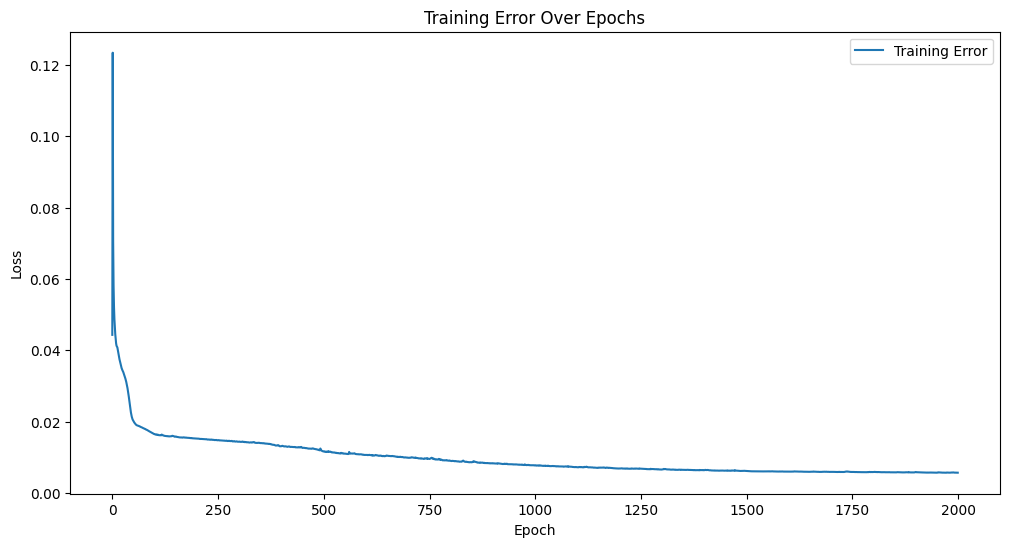

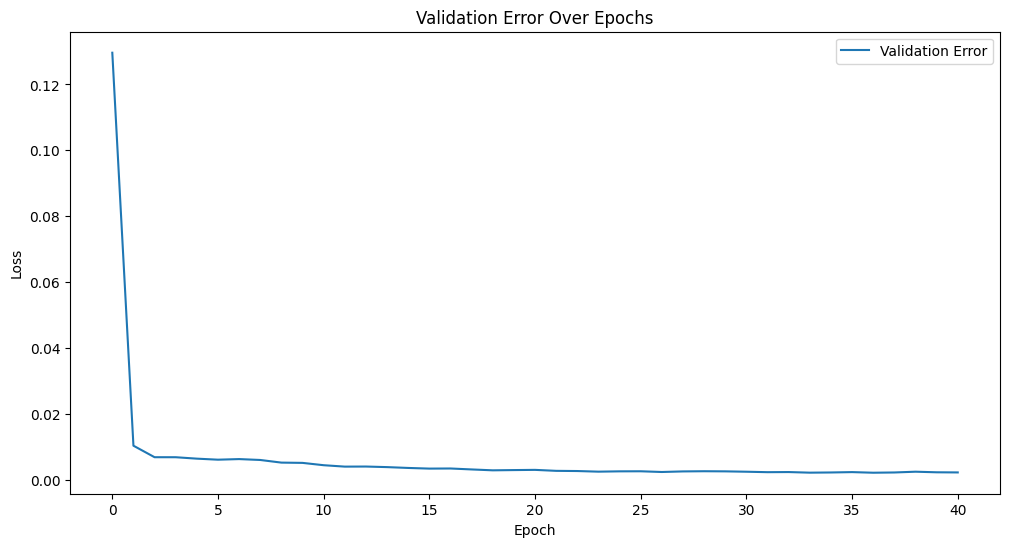

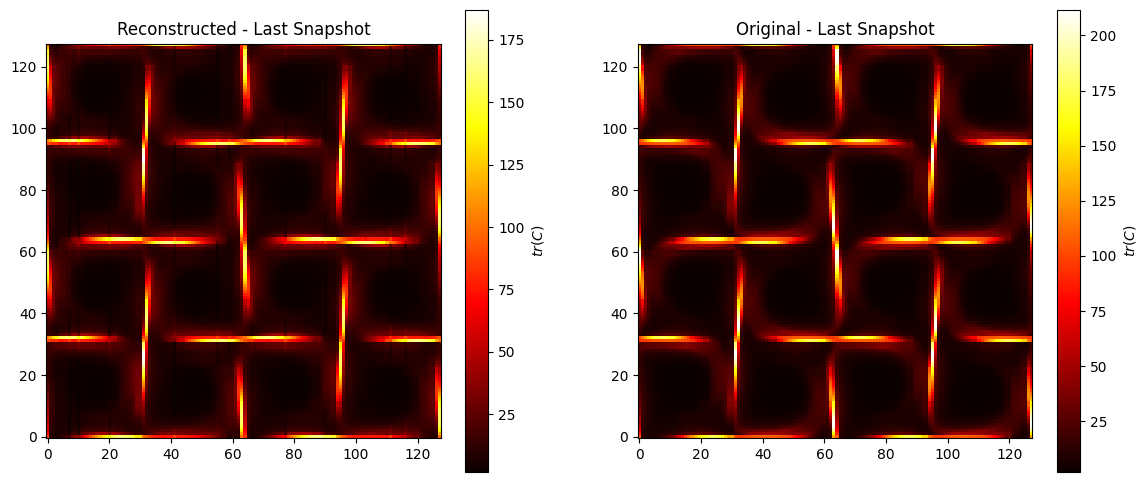

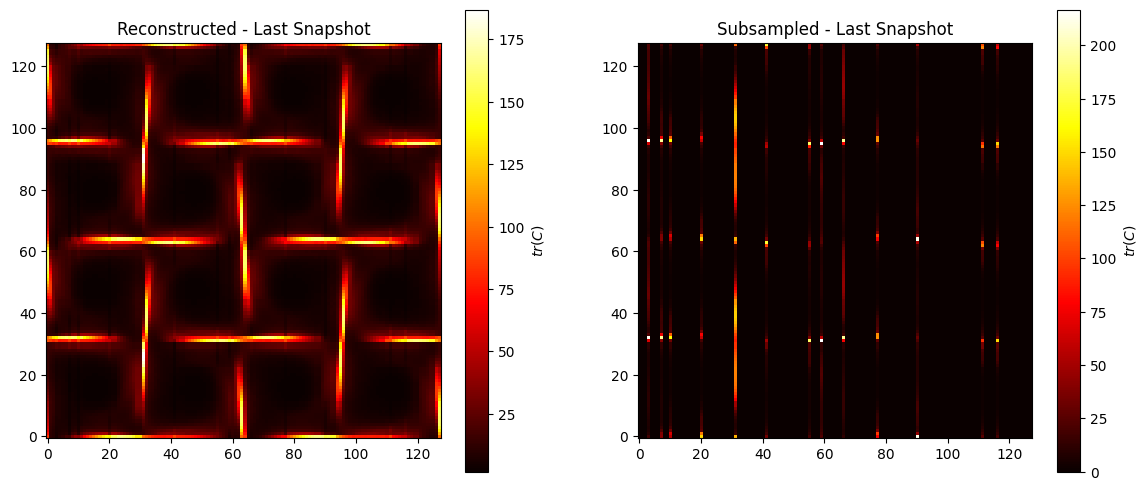

SSIM for the last snapshot: 0.9534496285724114
MSE for the last snapshot: 0.27029654383659363
PSNR for the last snapshot: 28.838269436324822 dB
Mean SSIM for all snapshots: 0.9290061873533028
Mean PSNR for all snapshots: 27.78703294558259 dB
Results saved to ./home/romulo/Documentos/lpips-env/results/shred/oldroyd/results.json
Plots saved to ./home/romulo/Documentos/lpips-env/results/shred/oldroyd


In [9]:
import json
import os
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from skimage.metrics import structural_similarity as ssim

def plot_results(
    train_error, validation_errors, test_recons, test_ground_truth, matrix, subsampled,
    save_path=r'./results/csshred/oldroyd/'
):
    os.makedirs(save_path, exist_ok=True)
    
    dim_x, dim_y, dim_t = subsampled.shape

    test_ground_truth = test_ground_truth.copy().reshape(-1, dim_x, dim_y)
    test_ground_truth = np.transpose(test_ground_truth.copy(), (1, 2, 0))
   
    test_recons = test_recons.reshape(-1, dim_x, dim_y)
   
    subsampled = subsampled.reshape(dim_x, dim_y, -1)

    print("test_recons", test_recons.shape)
    print("test_ground_truth", test_ground_truth.shape)
    print("subsampled", subsampled.shape)

    # Plot Training Error
    plt.figure(figsize=(12, 6))
    plt.plot(train_error, label="Training Error")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Error Over Epochs")
    plt.legend()
    training_error_plot_path = os.path.join(save_path, "training_error.png")
    plt.savefig(training_error_plot_path)
    plt.show()

    # Plot Validation Error
    plt.figure(figsize=(12, 6))
    plt.plot(validation_errors, label="Validation Error")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Validation Error Over Epochs")
    plt.legend()
    validation_error_plot_path = os.path.join(save_path, "validation_error.png")
    plt.savefig(validation_error_plot_path)
    plt.show()

    # Plot Last Snapshot - Reconstructed and Original
    plt.figure(figsize=(14, 6))

    ax1 = plt.subplot(1, 2, 1)
    img1 = ax1.imshow(test_recons[-1, :, :], cmap="hot", origin="lower")
    fig1 = plt.gcf()
    cbar1 = fig1.colorbar(img1, ax=ax1, label=r"$tr(C)$")
    plt.title("Reconstructed - Last Snapshot")
    
    ax2 = plt.subplot(1, 2, 2)
    img2 = ax2.imshow(test_ground_truth[:, :, -1], cmap="hot", origin="lower")
    fig2 = plt.gcf()
    cbar2 = fig2.colorbar(img2, ax=ax2, label=r"$tr(C)$")
    plt.title("Original - Last Snapshot")
    
    last_snapshot_plot_path = os.path.join(save_path, "last_snapshot_comparison.png")
    plt.savefig(last_snapshot_plot_path)
    plt.show()

    # Plot Last Snapshot - Reconstructed and Subsampled
    plt.figure(figsize=(14, 6))
    
    ax3 = plt.subplot(1, 2, 1)
    img3 = ax3.imshow(test_recons[-1, :, :], cmap="hot", origin="lower")
    fig3 = plt.gcf()
    cbar3 = fig3.colorbar(img3, ax=ax3, label=r"$tr(C)$")
    plt.title("Reconstructed - Last Snapshot")
    
    ax4 = plt.subplot(1, 2, 2)
    img4 = ax4.imshow(subsampled[:, :, -1], cmap="hot", origin="lower")
    fig4 = plt.gcf()
    cbar4 = fig4.colorbar(img4, ax=ax4, label=r"$tr(C)$")
    plt.title("Subsampled - Last Snapshot")
    
    subsampled_snapshot_plot_path = os.path.join(save_path, "subsampled_snapshot_comparison.png")
    plt.savefig(subsampled_snapshot_plot_path)
    plt.show()
    
    # Calculando o SSIM, MSE e PSNR para o último snapshot
    ssim_value_last = ssim(
        test_ground_truth[:, :, -1],
        test_recons[-1, :, :],
        data_range=test_ground_truth[:, :, -1].max()
        - test_ground_truth[:, :, -1].min(),
    )
    test_recons_mse = np.transpose(test_recons.copy(), (1,2,0))
    mse_value_last = np.linalg.norm(test_recons_mse - test_ground_truth) / np.linalg.norm(test_ground_truth)
    
    # Calculando o PSNR para o último snapshot
    mse = mean_squared_error(test_ground_truth[:, :, -1], test_recons[-1, :, :])
    max_pixel = np.max(test_ground_truth[:, :, -1])
    psnr_value_last = 20 * log10(max_pixel / np.sqrt(mse))
    
    print(f"SSIM for the last snapshot: {ssim_value_last}")
    print(f"MSE for the last snapshot: {mse_value_last}")
    print(f"PSNR for the last snapshot: {psnr_value_last} dB")
    
    # Calculando a média dos SSIMs e PSNRs para todos os snapshots
    ssim_values = []
    psnr_values = []
    for i in range(test_recons.shape[0]):
        ssim_value = ssim(
            test_ground_truth[:, :, i],
            test_recons[i, :, :],
            data_range=test_ground_truth[:, :, i].max()
            - test_ground_truth[:, :, i].min(),
        )
        ssim_values.append(ssim_value)
        
        mse = mean_squared_error(test_ground_truth[:, :, i], test_recons[i, :, :])
        max_pixel = np.max(test_ground_truth[:, :, i])
        psnr = 20 * log10(max_pixel / np.sqrt(mse))
        psnr_values.append(psnr)
    
    mean_ssim_value = np.mean(ssim_values)
    mean_psnr_value = np.mean(psnr_values)
    print(f"Mean SSIM for all snapshots: {mean_ssim_value}")
    print(f"Mean PSNR for all snapshots: {mean_psnr_value} dB")

    # Salvando as informações em um arquivo JSON no caminho especificado
    results = {
        "SSIM_last_snapshot": float(ssim_value_last),
        "MSE_last_snapshot": float(mse_value_last),
        "PSNR_last_snapshot": float(psnr_value_last),
        "Mean_SSIM_all_snapshots": float(mean_ssim_value),
        "Mean_PSNR_all_snapshots": float(mean_psnr_value),
    }
    
    json_file_path = os.path.join(save_path, "results.json")
    with open(json_file_path, "w") as json_file:
        json.dump(results, json_file, indent=4)
    
    print(f"Results saved to {json_file_path}")
    print(f"Plots saved to {save_path}")

plot_results(
    train_error, validation_errors, test_recons, test_ground_truth, matrix, snapshot,
    save_path=save_path)

# SHRED

In [12]:
import lpips

# Criando o modelo LPIPS
loss_fn = lpips.LPIPS(net='alex', use_dropout=True)  # ou 'vgg'

# Convertendo imagens para tensores e normalizando
img0 = torch.from_numpy(test_ground_truth).unsqueeze(0).float()  # Ground truth
img1 = torch.from_numpy(test_recons).unsqueeze(0).float()  # Reconstructed

# Avaliação da similaridade perceptual
d = loss_fn(img0, img1)

print(f'LPIPS (perceptual loss): {d.item()}')

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/romulo/Documentos/lpips-env/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/romulo/Documentos/lpips-env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/romulo/Documentos/lpips-env/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth
LPIPS (perceptual loss): 0.10690562427043915


test_recons (141, 128, 128)
test_ground_truth (128, 128, 141)
subsampled (128, 128, 1433)


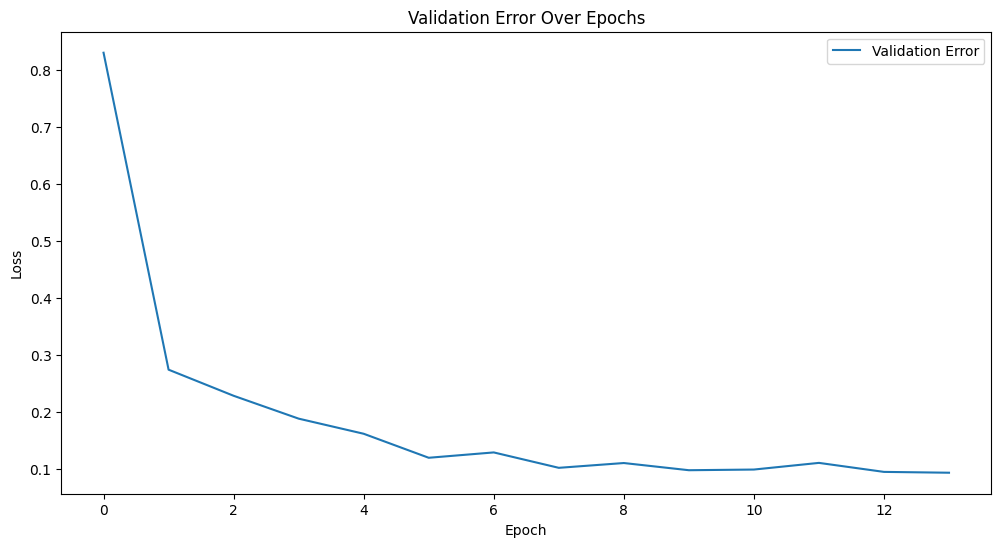

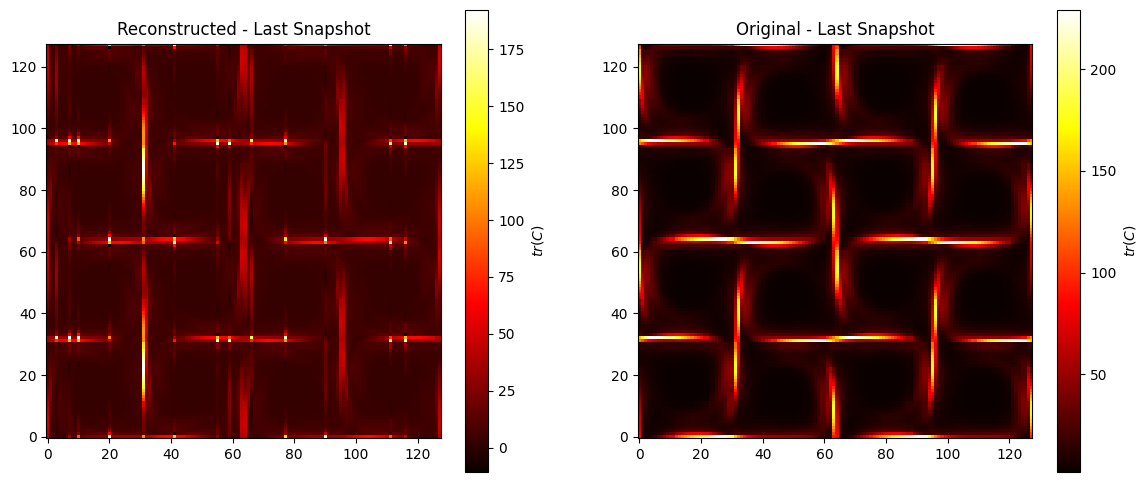

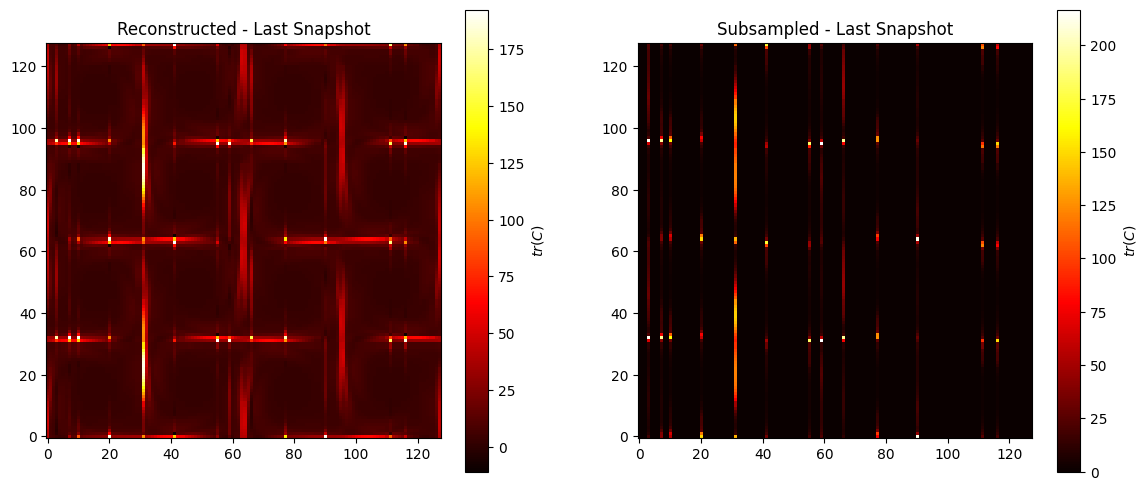

SSIM for the last snapshot: 0.6183986933810395
MSE for the last snapshot: 0.4915529489517212
PSNR for the last snapshot: 18.29695593425233 dB
Mean SSIM for all snapshots: 0.8045060644605534
Mean PSNR for all snapshots: 22.57934356774156 dB
Results saved to ./home/romulo/Documentos/lpips-env/results/shred/oldroyd/results_shred_oldroyd.json
Plots saved to ./home/romulo/Documentos/lpips-env/results/shred/oldroyd


In [13]:


def plot_results(
    validation_errors, test_recons, test_ground_truth, matrix, subsampled,
    save_path=r'./results/shred/oldroyd/'
):
    # Certifique-se de que o diretório de salvamento existe
    os.makedirs(save_path, exist_ok=True)
    
    dim_x, dim_y, dim_t = subsampled.shape

    test_ground_truth = test_ground_truth.copy().reshape(-1, dim_x, dim_y)
    test_ground_truth = np.transpose(test_ground_truth.copy(), (1, 2, 0))
   
    test_recons = test_recons.reshape(-1, dim_x, dim_y)
   
    subsampled = subsampled.reshape(dim_x, dim_y, -1)

    print("test_recons", test_recons.shape)
    print("test_ground_truth", test_ground_truth.shape)
    print("subsampled", subsampled.shape)

    # Plot Training Error
    # plt.figure(figsize=(12, 6))
    # plt.plot(train_error, label="Training Error")
    # plt.xlabel("Epoch")
    # plt.ylabel("Loss")
    # plt.title("Training Error Over Epochs")
    # plt.legend()
    # training_error_plot_path = os.path.join(save_path, "training_error.png")
    # plt.savefig(training_error_plot_path)
    # plt.show()

    # Plot Validation Error
    plt.figure(figsize=(12, 6))
    plt.plot(validation_errors, label="Validation Error")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Validation Error Over Epochs")
    plt.legend()
    validation_error_plot_path = os.path.join(save_path, "validation_error.png")
    plt.savefig(validation_error_plot_path)
    plt.show()

    # Plot Last Snapshot - Reconstructed and Original
    plt.figure(figsize=(14, 6))

    ax1 = plt.subplot(1, 2, 1)
    img1 = ax1.imshow(test_recons[-1, :, :], cmap="hot", origin="lower")
    fig1 = plt.gcf()
    cbar1 = fig1.colorbar(img1, ax=ax1, label=r"$tr(C)$")
    plt.title("Reconstructed - Last Snapshot")
    
    ax2 = plt.subplot(1, 2, 2)
    img2 = ax2.imshow(test_ground_truth[:, :, -1], cmap="hot", origin="lower")
    fig2 = plt.gcf()
    cbar2 = fig2.colorbar(img2, ax=ax2, label=r"$tr(C)$")
    plt.title("Original - Last Snapshot")
    
    last_snapshot_plot_path = os.path.join(save_path, "last_snapshot_comparison.png")
    plt.savefig(last_snapshot_plot_path)
    plt.show()

    # Plot Last Snapshot - Reconstructed and Subsampled
    plt.figure(figsize=(14, 6))
    
    ax3 = plt.subplot(1, 2, 1)
    img3 = ax3.imshow(test_recons[-1, :, :], cmap="hot", origin="lower")
    fig3 = plt.gcf()
    cbar3 = fig3.colorbar(img3, ax=ax3, label=r"$tr(C)$")
    plt.title("Reconstructed - Last Snapshot")
    
    ax4 = plt.subplot(1, 2, 2)
    img4 = ax4.imshow(subsampled[:, :, -1], cmap="hot", origin="lower")
    fig4 = plt.gcf()
    cbar4 = fig4.colorbar(img4, ax=ax4, label=r"$tr(C)$")
    plt.title("Subsampled - Last Snapshot")
    
    subsampled_snapshot_plot_path = os.path.join(save_path, "subsampled_snapshot_comparison.png")
    plt.savefig(subsampled_snapshot_plot_path)
    plt.show()
    
    # Calculando o SSIM, MSE e PSNR para o último snapshot
    # Calculando o SSIM, MSE e PSNR para o último snapshot
    ssim_value_last = ssim(
        test_ground_truth[:, :, -1],
        test_recons[-1, :, :],
        data_range=test_ground_truth[:, :, -1].max() - test_ground_truth[:, :, -1].min(),
    )
    test_recons_mse = np.transpose(test_recons.copy(), (1,2,0))
    mse_value_last = np.linalg.norm(test_recons_mse - test_ground_truth) / np.linalg.norm(test_ground_truth)
    
    # Calculando o PSNR para o último snapshot
    mse = mean_squared_error(test_ground_truth[:, :, -1], test_recons[-1, :, :])
    max_pixel = np.max(test_ground_truth[:, :, -1])
    psnr_value_last = 20 * log10(max_pixel / np.sqrt(mse))
    
    
    print(f"SSIM for the last snapshot: {ssim_value_last}")
    print(f"MSE for the last snapshot: {mse_value_last}")
    print(f"PSNR for the last snapshot: {psnr_value_last} dB")
    
    # Calculando a média dos SSIMs, PSNRs e NPSs para todos os snapshots
    ssim_values = []
    psnr_values = []
    nps_values = []
    for i in range(test_recons.shape[0]):
        ssim_value = ssim(
            test_ground_truth[:, :, i],
            test_recons[i, :, :],
            data_range=test_ground_truth[:, :, i].max() - test_ground_truth[:, :, i].min(),
        )
        ssim_values.append(ssim_value)
        
        mse = mean_squared_error(test_ground_truth[:, :, i], test_recons[i, :, :])
        max_pixel = np.max(test_ground_truth[:, :, i])
        psnr = 20 * log10(max_pixel / np.sqrt(mse))
        psnr_values.append(psnr)
        
    
    mean_ssim_value = np.mean(ssim_values)
    mean_psnr_value = np.mean(psnr_values)
    print(f"Mean SSIM for all snapshots: {mean_ssim_value}")
    print(f"Mean PSNR for all snapshots: {mean_psnr_value} dB")

    # Salvando as informações em um arquivo JSON no caminho especificado
    results = {
        "SSIM_last_snapshot": float(ssim_value_last),
        "MSE_last_snapshot": float(mse_value_last),
        "PSNR_last_snapshot": float(psnr_value_last),
        "Mean_SSIM_all_snapshots": float(mean_ssim_value),
        "Mean_PSNR_all_snapshots": float(mean_psnr_value),
        # "Mean_NPS_all_snapshots": float(mean_nps_value),
    }
    
    json_file_path = os.path.join(save_path, "results_shred_oldroyd.json")
    with open(json_file_path, "w") as json_file:
        json.dump(results, json_file, indent=4)
    
    print(f"Results saved to {json_file_path}")
    print(f"Plots saved to {save_path}")


plot_results(
    validation_errors, test_recons, test_ground_truth, matrix, snapshot,save_path=save_path
)